# 01 — Analisi esplorativa dei dati (EDA)

Esplora il dataset pulito prima di interpretare le spiegazioni XAI.
Questo notebook non addestra nessun modello: legge solo i dati processati.

Prima di committare: Kernel → Restart & Clear Output.

## 0. Carico il dataset pulito

In [1]:
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / "data" / "heart-disease-UCI.csv")
print("Shape:", df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 1. Bilanciamento del target

In [4]:
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).round(3))

target
1    165
0    138
Name: count, dtype: int64

target
1    0.545
0    0.455
Name: proportion, dtype: float64


## 2. Statistiche descrittive

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.37,9.08,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.97,1.03,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.62,17.54,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.26,51.83,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.53,0.53,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.65,22.91,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


## 3. Distribuzioni delle feature continue

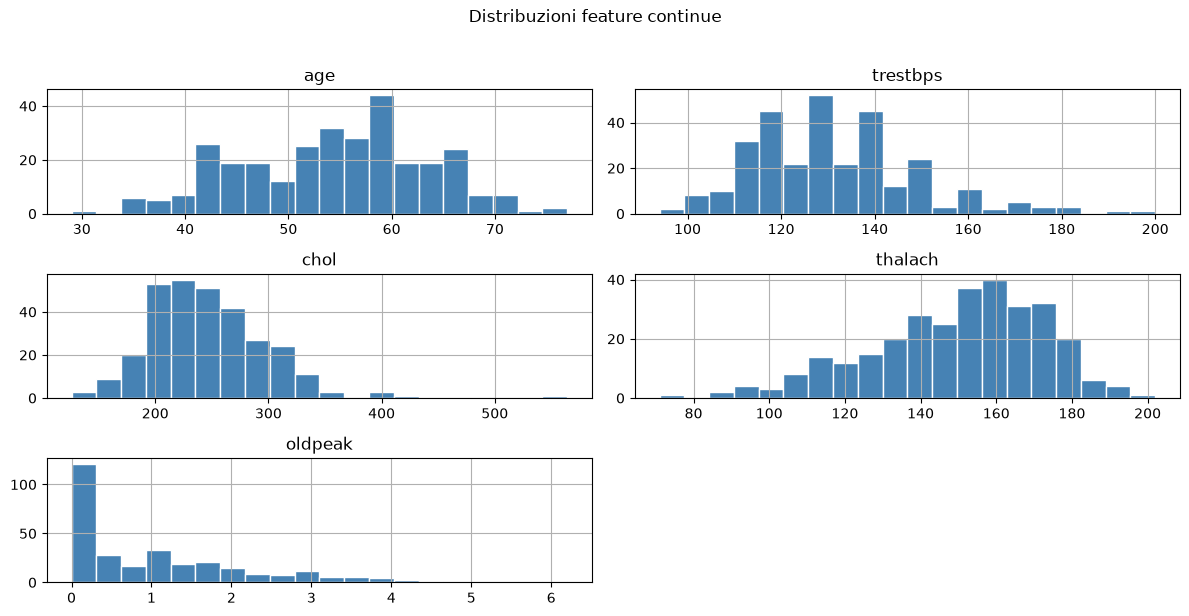

In [6]:
cont = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df[cont].hist(figsize=(12, 6), bins=20, color="steelblue", edgecolor="white")
plt.suptitle("Distribuzioni feature continue", y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature categoriche vs target

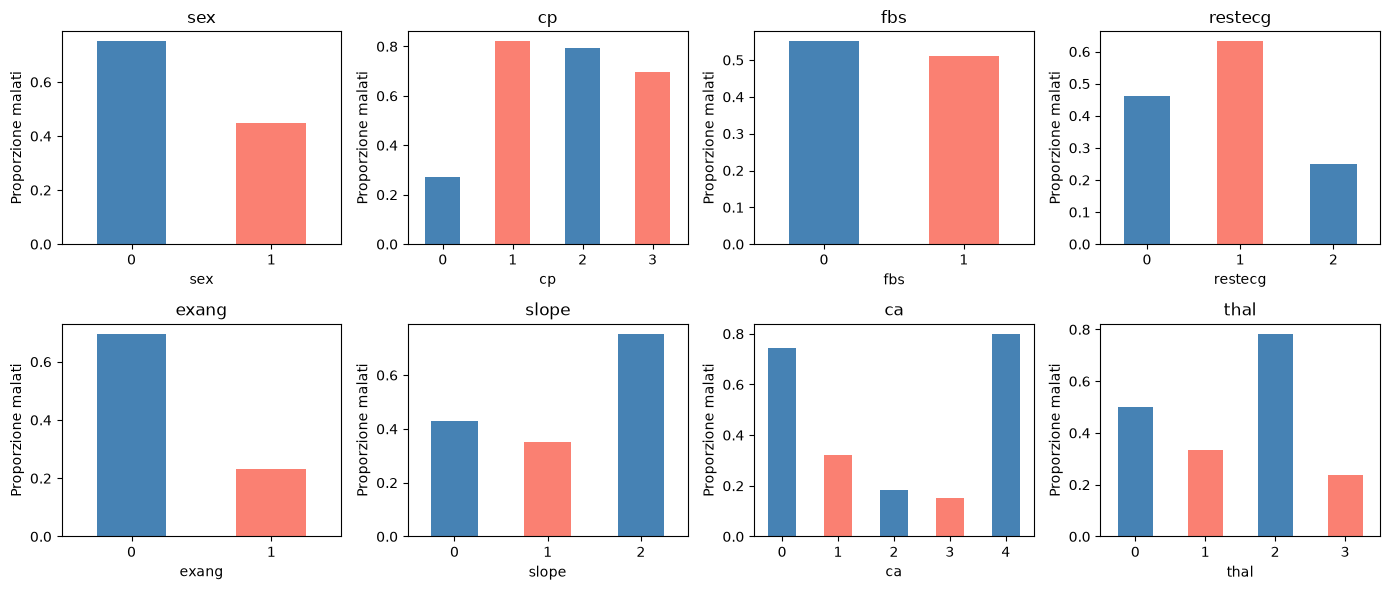

In [7]:
cat = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flatten(), cat):
    df.groupby(col)["target"].mean().plot.bar(ax=ax, color=["steelblue", "salmon"])
    ax.set_title(col)
    ax.set_ylabel("Proporzione malati")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 5. Correlazione con il target

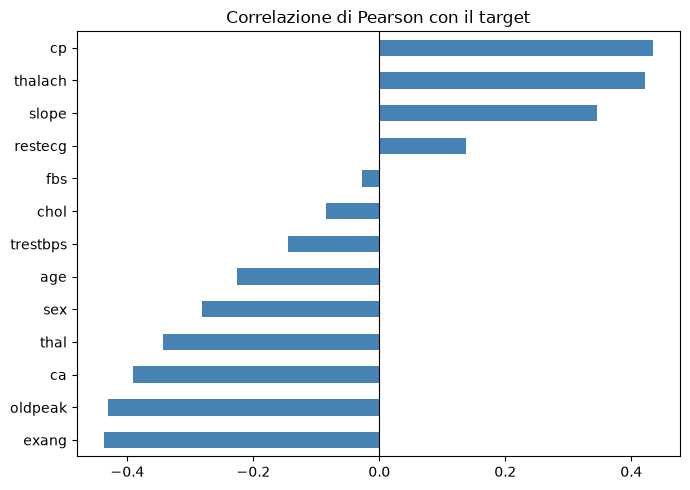

In [8]:
(df.corr(numeric_only=True)["target"]
   .drop("target")
   .sort_values()
   .plot.barh(figsize=(7, 5), color="steelblue"))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlazione di Pearson con il target")
plt.tight_layout()
plt.show()

## 6. Matrice di correlazione tra feature

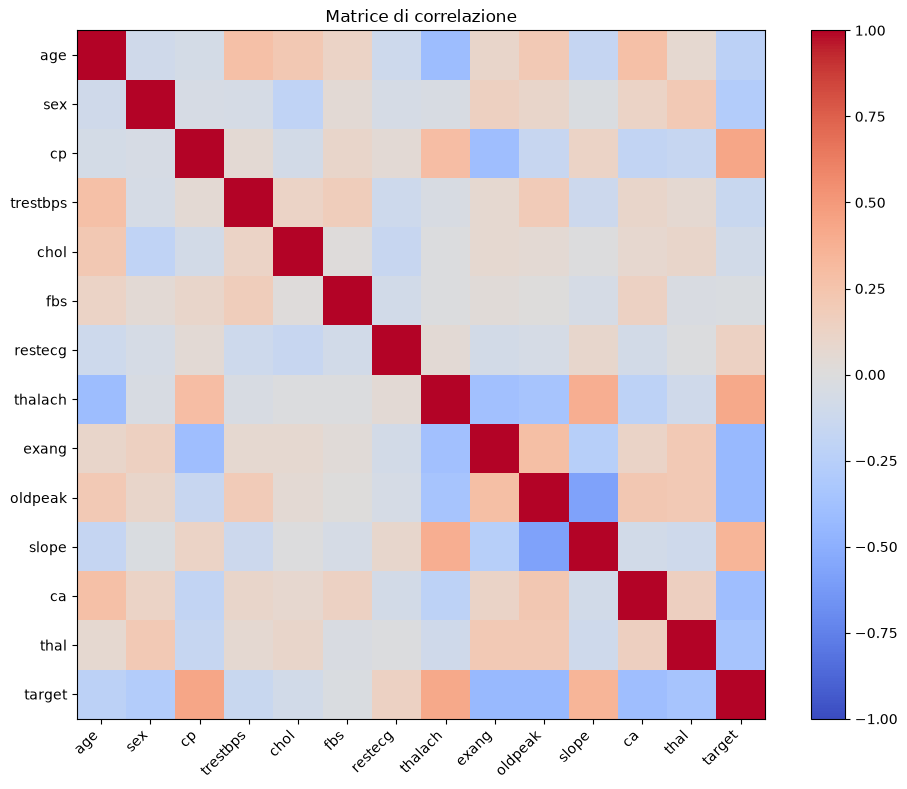

In [9]:
import matplotlib.cm as cm
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
plt.title("Matrice di correlazione")
plt.tight_layout()
plt.show()